# 02 — Feature Engineering & EDA

Build the modelling-ready dataset from raw lap data, then do some quick EDA.

**Target**: `pit_this_lap` — 1 if a driver pits on this lap, 0 otherwise.

**Train**: 2022–2024 seasons | **Test**: 2025 season

## Setup

In [33]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.dpi"] = 110
sns.set_theme(style="darkgrid")

## Load raw data

In [34]:
df = pd.read_csv("../data/raw/all_laps.csv", low_memory=False)
print(f"Raw shape: {df.shape}")
df.head(3)

Raw shape: (100134, 54)


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,pit_lane_speed_limit_kmh,pit_loss_delta_s,direction,elevation_change_m,overtaking_difficulty,tyre_stress,in_2022,in_2023,in_2024,notes
0,0 days 01:04:15.340000,VER,1,0 days 00:01:40.236000,1.0,1.0,NaN,NaN,NaN,0 days 00:00:42.325000,...,80,22.0,Clockwise,37,Low,High,1,1,1,Night race; desert abrasive surface; high tyre...
1,0 days 01:05:53.220000,VER,1,0 days 00:01:37.880000,2.0,1.0,NaN,NaN,0 days 00:00:31.285000,0 days 00:00:42.269000,...,80,22.0,Clockwise,37,Low,High,1,1,1,Night race; desert abrasive surface; high tyre...
2,0 days 01:07:31.577000,VER,1,0 days 00:01:38.357000,3.0,1.0,NaN,NaN,0 days 00:00:31.499000,0 days 00:00:42.474000,...,80,22.0,Clockwise,37,Low,High,1,1,1,Night race; desert abrasive surface; high tyre...


## Drop columns not useful for modelling

Removed:
- **Identity / lookup**: `Time`, `DriverNumber`, `LapStartTime`, `LapStartDate`, `grand_prix`, `circuit_name`, `city`, `country`, `in_2022/23/24`, `notes`
- **Telemetry** (not reliable for all laps): `SpeedI1`, `SpeedI2`, `SpeedFL`, `SpeedST`
- **Post-hoc flags**: `IsPersonalBest`, `Deleted`, `DeletedReason`, `FastF1Generated`, `IsAccurate`
- **Sector session timestamps**: `Sector1SessionTime`, `Sector2SessionTime`, `Sector3SessionTime`
- **Raw pit timestamps** (replaced by binary target): `PitInTime`, `PitOutTime`

In [35]:
DROP_COLS = [
    "Time", "DriverNumber", "LapStartTime", "LapStartDate",
    "grand_prix", "circuit_name", "city", "country",
    "in_2022", "in_2023", "in_2024", "notes",
    "SpeedI1", "SpeedI2", "SpeedFL", "SpeedST",
    "IsPersonalBest", "Deleted", "DeletedReason",
    "FastF1Generated", "IsAccurate",
    "Sector1SessionTime", "Sector2SessionTime", "Sector3SessionTime",
]

df = df.drop(columns=DROP_COLS, errors="ignore")
print(f"After drop: {df.shape}")

After drop: (100134, 30)


In [36]:
# Quick null check before we start cleaning
df.isnull().sum()

Driver                          0
LapTime                      1539
LapNumber                       0
Stint                         354
PitOutTime                  96694
PitInTime                   96692
Sector1Time                  2074
Sector2Time                   169
Sector3Time                   282
Compound                      780
TyreLife                      989
FreshTyre                       0
Team                            0
TrackStatus                     0
Position                      135
EventName                       0
Season                          0
circuit_key                     0
circuit_type                    0
track_length_km                 0
num_corners                     0
num_drs_zones                   0
race_laps                       0
race_distance_km                0
pit_lane_speed_limit_kmh        0
pit_loss_delta_s                0
direction                       0
elevation_change_m              0
overtaking_difficulty           0
tyre_stress   

### Why these nulls are fine

**`PitInTime` / `PitOutTime` (~96,700 nulls each)** — expected. A null means the driver didn't pit on that lap. Since only ~3.5% of laps are pit laps, most rows will be null here. We convert `PitInTime` into our binary target and drop both columns.

**`LapTime` (~1,500 nulls)** — usually the in-lap or the first lap of a stint where timing is unreliable. We keep pit laps even without a lap time, then fill the rest.

**`Stint` / `Compound` / `TyreLife` (~350–990 nulls)** — mostly lap 1 or the first lap of a new stint before FastF1 has confirmed the tyre

**`Position` (~135 nulls)** — occasional telemetry gaps during saftey car restarts etc where positions are still calculated this is not an issue 

**`Sector1/2/3Time` (~170–280 nulls)** — laps where sector timing was lost (usually pit entry/exit). Filled later with `LapTime / 3` as a rough estimate.


## Target variable — `pit_this_lap`

A lap is a pit lap if the driver crossed the pit entry line on that lap.
FastF1 records this as a non-null `PitInTime`.

In [37]:
df["pit_this_lap"] = df["PitInTime"].notna().astype(int)
df = df.drop(columns=["PitInTime", "PitOutTime"], errors="ignore")

print(f"Pit laps : {df['pit_this_lap'].sum():,}")
print(f"Non-pit  : {(df['pit_this_lap']==0).sum():,}")
print(f"Pit rate : {df['pit_this_lap'].mean()*100:.2f}%")

Pit laps : 3,442
Non-pit  : 96,692
Pit rate : 3.44%


## Convert timedeltas to seconds

FastF1 stores times as strings like `0 days 00:01:32.456`. We convert all of them to float seconds.

In [38]:
TIME_COLS = ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]

for col in TIME_COLS:
    df[col] = pd.to_timedelta(df[col], errors="coerce").dt.total_seconds()

df[TIME_COLS].describe().round(2)

,LapTime,Sector1Time,Sector2Time,Sector3Time
count,98595.00,98060.00,99965.00,99852.00
mean,92.06,28.78,35.52,28.14
std,33.66,7.36,8.20,7.72
min,67.01,16.84,17.49,16.54
25%,81.51,24.64,29.89,23.11
50%,89.97,28.77,33.43,26.11
75%,99.17,31.64,41.29,31.33
max,2526.25,98.79,92.61,99.74


## Clean nulls and filter bad laps

Steps:
1. Sort by season / event / driver / lap so fills work sequentially
2. Fill `Stint` nulls (mostly lap 1) with forward/backward fill
3. Fill `Compound` within each stint (constant within a stint)
4. Drop rows with unknown compound
5. Fill `Position` nulls with forward/backward fill
6. Fill `TyreLife` within each stint
7. Keep pit laps even if `LapTime` is null, but drop non-pit laps with null `LapTime`
8. Remove lap 1 and extreme lap times (likely SC / formation laps)

In [39]:
before = len(df)

# Sort first so rolling fills work in the right direction
df = df.sort_values(["Season", "EventName", "Driver", "LapNumber"]).reset_index(drop=True)

In [40]:
# Fill Stint and Compound nulls within each driver/race group
# we can do this because the tyre compound dosent change within a stint 
grp_race  = ["Season", "EventName", "Driver"]
grp_stint = ["Season", "EventName", "Driver", "Stint"]

df["Stint"] = df.groupby(grp_race)["Stint"].ffill().bfill()
df["Stint"] = df["Stint"].fillna(1)

df["Compound"] = df.groupby(grp_stint)["Compound"].ffill().bfill()
df = df[df["Compound"].isin(["SOFT", "MEDIUM", "HARD", "INTERMEDIATE", "WET"])]

In [41]:
# Drop rows where Position is unknown rather than guessing it
df = df[df["Position"].notna()]



In [42]:
df = df[df["LapTime"].notna() | (df["pit_this_lap"] == 1)]
df["LapTime"] = df.groupby(grp_race)["LapTime"].ffill().bfill()

df = df[df["LapNumber"] > 1]
df = df[(df["LapTime"] >= 50) & (df["LapTime"] <= 300)]

print(f"Dropped {before - len(df):,} rows → {len(df):,} remain")


Dropped 3,055 rows → 97,079 remain


## Track status — extract SC and VSC flags

FastF1's `TrackStatus` is a string of active flag codes:
- `4` = Safety Car
- `5` = Red Flag
- `6` / `7` = VSC / VSC ending

Teams almost always pit under safety car, so these flags matter a lot.

In [43]:
df["TrackStatus"] = df["TrackStatus"].astype(str)

df["sc_active"]  = df["TrackStatus"].str.contains("4").astype(int)
df["vsc_active"] = df["TrackStatus"].str.contains("6|7").astype(int)
df["red_flag"]   = df["TrackStatus"].str.contains("5").astype(int)

df = df.drop(columns=["TrackStatus"])

print(df[["sc_active", "vsc_active", "red_flag"]].sum())

sc_active     4111
vsc_active    1859
red_flag       164
dtype: int64


## Race-state features

Computed per driver per race: laps remaining, race completion %, and lap within the current stint.

In [44]:
# Re-sort to be safe before computing stint lap numbers
df = df.sort_values(["Season", "EventName", "Driver", "LapNumber"]).reset_index(drop=True)

df["laps_remaining"] = df["race_laps"] - df["LapNumber"]
df["race_pct"]       = df["LapNumber"] / df["race_laps"]

In [45]:
# Lap counter within the current stint (resets to 1 on each new stint) (we are calculating this because tyre life is the total number of laps the tyre has done which includes all the other sessions)
df["stint_lap"] = df.groupby(
    ["Season", "EventName", "Driver", "Stint"]
)["LapNumber"].transform(lambda x: range(1, len(x) + 1))

# Fall back to stint_lap for any remaining TyreLife nulls
df["TyreLife"] = df["TyreLife"].fillna(df["stint_lap"])

df[["LapNumber", "race_laps", "laps_remaining", "race_pct", "Stint", "stint_lap", "TyreLife"]].head(10)

,LapNumber,race_laps,laps_remaining,race_pct,Stint,stint_lap,TyreLife
0,2.0,58,56.0,0.034483,1.0,1,2.0
1,3.0,58,55.0,0.051724,1.0,2,3.0
2,4.0,58,54.0,0.068966,1.0,3,4.0
3,5.0,58,53.0,0.086207,1.0,4,5.0
4,6.0,58,52.0,0.103448,1.0,5,6.0
5,7.0,58,51.0,0.120690,1.0,6,7.0
6,8.0,58,50.0,0.137931,1.0,7,8.0
7,9.0,58,49.0,0.155172,1.0,8,9.0
8,10.0,58,48.0,0.172414,1.0,9,10.0
9,11.0,58,47.0,0.189655,1.0,10,11.0


## Lap-time degradation features

Three signals to capture how much the tyre is worn down within a stint:
- **Rolling 3-lap median** — smoothed pace
- **Delta from best lap in stint** — cumulative degradation
- **Delta from previous lap** — immediate change

In [46]:
grp = df.groupby(["Season", "EventName", "Driver", "Stint"])["LapTime"]

df["lap_time_roll3"]       = grp.transform(lambda x: x.rolling(3, min_periods=1).median())
df["lap_time_delta_best"]  = df["LapTime"] - grp.transform("min")
df["lap_time_delta_prev"]  = grp.transform(lambda x: x.diff().fillna(0))

df[["LapTime", "lap_time_roll3", "lap_time_delta_best", "lap_time_delta_prev"]].describe().round(3)

,LapTime,lap_time_roll3,lap_time_delta_best,lap_time_delta_prev
count,97079.000,97079.000,97079.000,97079.000
mean,91.451,91.566,3.400,-0.511
std,13.833,13.809,8.537,6.680
min,67.012,67.804,0.000,-64.690
25%,81.422,81.481,0.396,-0.290
50%,89.712,89.877,0.825,0.000
75%,99.018,99.150,1.701,0.244
max,182.581,182.581,73.557,61.267


## Encode categorical features

Ordinal encoding for compound (softer = 0, harder = higher), circuit type, overtaking difficulty, and tyre stress. Direction becomes a simple binary flag.

In [47]:
compound_map = {"SOFT": 0, "MEDIUM": 1, "HARD": 2, "INTERMEDIATE": 3, "WET": 4}
df["compound_enc"] = df["Compound"].map(compound_map)

circuit_type_map = {"Permanent": 0, "Semi-Permanent": 1, "Street": 2}
df["circuit_type_enc"] = df["circuit_type"].map(circuit_type_map)

od_map = {"Low": 0, "Medium": 1, "High": 2, "Very High": 3, "Extremely High": 4}
df["overtaking_difficulty_enc"] = df["overtaking_difficulty"].map(od_map)

ts_map = {"Low": 0, "Medium": 1, "High": 2}
df["tyre_stress_enc"] = df["tyre_stress"].map(ts_map)

df["clockwise"]  = (df["direction"] == "Clockwise").astype(int)
df["fresh_tyre"] = df["FreshTyre"].astype(int)

In [48]:
# Drop original string columns (keep circuit_key as a grouping reference)
df = df.drop(columns=["Compound", "circuit_type", "overtaking_difficulty",
                      "tyre_stress", "direction", "FreshTyre", "Team",
                      "Driver", "EventName"])

print(df.dtypes.value_counts())

int64      17
float64    16
object      1
Name: count, dtype: int64


## Final null check

In [49]:
null_counts = df.isna().sum()
null_counts[null_counts > 0].sort_values(ascending=False)

Sector3Time    101
Sector1Time     47
Sector2Time     25
dtype: int64

In [50]:
# Drop the tiny number of rows with missing sector times
before_sectors = len(df)
df = df.dropna(subset=["Sector1Time", "Sector2Time", "Sector3Time"])
print(f"Dropped {before_sectors - len(df)} rows with missing sector times → {len(df):,} remain")


Dropped 124 rows with missing sector times → 96,955 remain


## Final feature set

In [51]:
print(f"Shape: {df.shape}")
print(f"\nFeatures ({len(df.columns)-1}):")
print([c for c in df.columns if c != "pit_this_lap"])

Shape: (96955, 34)

Features (33):
['LapTime', 'LapNumber', 'Stint', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'TyreLife', 'Position', 'Season', 'circuit_key', 'track_length_km', 'num_corners', 'num_drs_zones', 'race_laps', 'race_distance_km', 'pit_lane_speed_limit_kmh', 'pit_loss_delta_s', 'elevation_change_m', 'sc_active', 'vsc_active', 'red_flag', 'laps_remaining', 'race_pct', 'stint_lap', 'lap_time_roll3', 'lap_time_delta_best', 'lap_time_delta_prev', 'compound_enc', 'circuit_type_enc', 'overtaking_difficulty_enc', 'tyre_stress_enc', 'clockwise', 'fresh_tyre']


---
## EDA
### Class balance

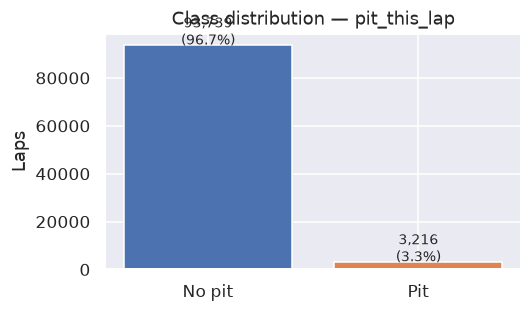

In [52]:
counts = df["pit_this_lap"].value_counts()
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["No pit", "Pit"], counts.values, color=["#4C72B0", "#DD8452"])
for i, v in enumerate(counts.values):
    ax.text(i, v + 200, f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=9)
ax.set_title("Class distribution — pit_this_lap")
ax.set_ylabel("Laps")
plt.tight_layout()
plt.show()

### Pit rate by compound

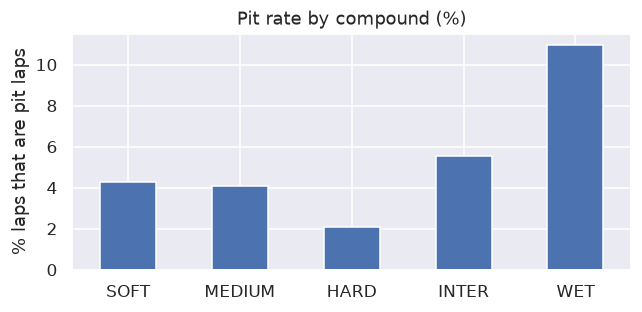

In [53]:
compound_labels = {0: "SOFT", 1: "MEDIUM", 2: "HARD", 3: "INTER", 4: "WET"}
pit_by_compound = df.groupby("compound_enc")["pit_this_lap"].mean() * 100
pit_by_compound.index = pit_by_compound.index.map(compound_labels)

fig, ax = plt.subplots(figsize=(6, 3))
pit_by_compound.plot(kind="bar", ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title("Pit rate by compound (%)")
ax.set_ylabel("% laps that are pit laps")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# We can see that inters and wets have the most pit rate while hard compound has the least

### Pit rate vs tyre age

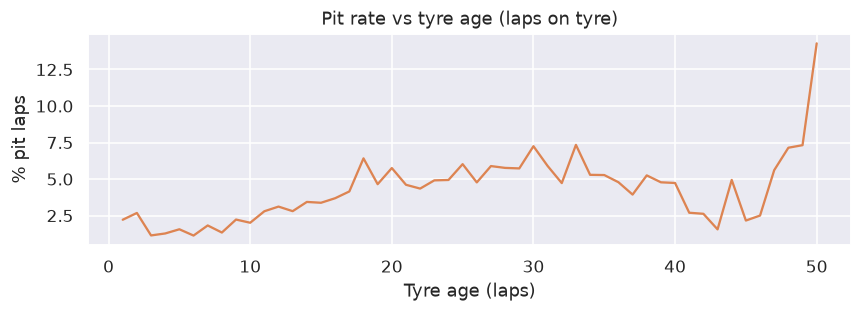

In [54]:
tyre_age_pit = (
    df[df["TyreLife"] <= 50]
    .groupby("TyreLife")["pit_this_lap"]
    .mean() * 100
)

fig, ax = plt.subplots(figsize=(8, 3))
tyre_age_pit.plot(ax=ax, color="#DD8452")
ax.set_title("Pit rate vs tyre age (laps on tyre)")
ax.set_xlabel("Tyre age (laps)")
ax.set_ylabel("% pit laps")
plt.tight_layout()
plt.show()

## as the tyre age increases the pit rate increases but we see a dip around the 40 laps region this is mostly due to the car finishing the race around that tyre age 

### Pit rate vs laps remaining

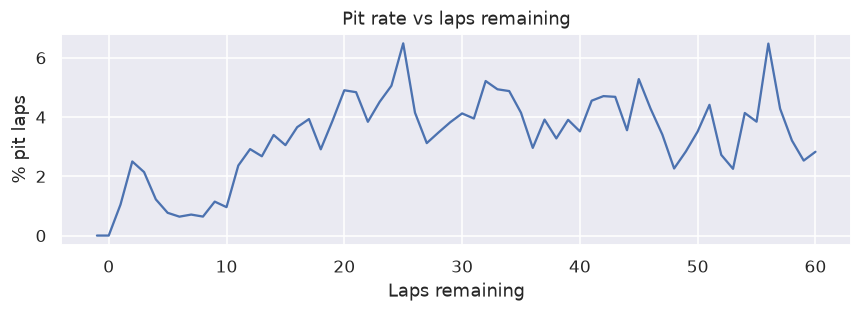

In [55]:
laps_remaining_pit = (
    df[df["laps_remaining"] <= 60]
    .groupby("laps_remaining")["pit_this_lap"]
    .mean() * 100
)

fig, ax = plt.subplots(figsize=(8, 3))
laps_remaining_pit.plot(ax=ax, color="#4C72B0")
ax.set_title("Pit rate vs laps remaining")
ax.set_xlabel("Laps remaining")
ax.set_ylabel("% pit laps")
plt.tight_layout()
plt.show()

### Pit rate under safety car vs normal racing

In [56]:
sc_pit = df.groupby("sc_active")["pit_this_lap"].mean() * 100
print("Pit rate (%)")
print(f"  Normal racing : {sc_pit[0]:.2f}%")
print(f"  Safety car    : {sc_pit[1]:.2f}%")

Pit rate (%)
  Normal racing : 2.79%
  Safety car    : 15.30%


# thre is high pit rate when a saftey car is deployed this is due to the reduced loss of time 

### Correlation heatmap (numeric features)

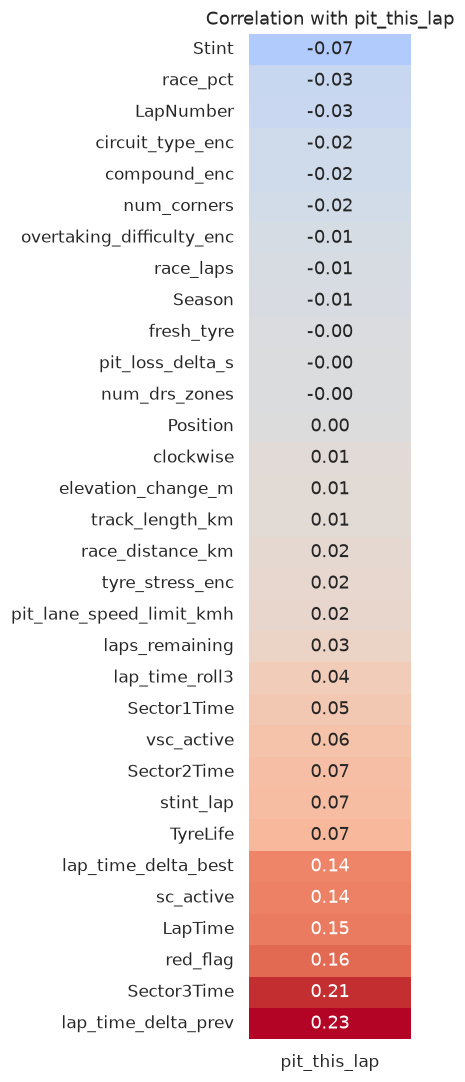

In [57]:
numeric_cols = df.select_dtypes(include=["number"]).columns.tolist()
corr = df[numeric_cols].corr()[["pit_this_lap"]].drop("pit_this_lap")

fig, ax = plt.subplots(figsize=(4, 10))
sns.heatmap(corr.sort_values("pit_this_lap"), annot=True, fmt=".2f",
            center=0, cmap="coolwarm", ax=ax, cbar=False)
ax.set_title("Correlation with pit_this_lap")
plt.tight_layout()
plt.show()

---
## Train / test split and save

2022–2024 = train, 2025 = test. This mirrors real usage — we train on historical seasons and predict the current one.

In [58]:
train = df[df["Season"] < 2025].copy()
test  = df[df["Season"] == 2025].copy()

print(f"Train: {train.shape}")
print(f"Test : {test.shape}")

Train: (72180, 34)
Test : (24775, 34)


In [59]:
train.to_csv(PROCESSED_DIR / "train.csv", index=False)
test.to_csv(PROCESSED_DIR  / "test.csv",  index=False)

print("Saved to data/processed/")

Saved to data/processed/
